## Slot Game Mathematical Model - Monte Carlo Simulation
### Setup : RTP=95% | Bet=$50 | 10000 Players | 20-2000 Hands

### Helper

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')


def setup_chinese_font():
    windows_fonts = ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei']
    
    available_fonts = [f.name for f in fm.fontManager.ttflist]

    for font in windows_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font

    print('⚠️ Can not find any Chinese word')
    return None

CHINESE_FONT = setup_chinese_font()

### Parameter Configuration

In [2]:
np.random.seed(42)

BET          = 50
TARGET_RTP   = 0.95
N_PLAYERS    = 10000
MIN_HANDS    = 20
MAX_HANDS    = 2000
SHOW_PLAYERS = 100


PAYTABLE = [
    ('頭獎',    1000, 0.00005),
    ('大獎',     200, 0.00010),
    ('高獎',      50, 0.00080),
    ('中高獎',    20, 0.00500),
    ('中獎',      10, 0.01500),
    ('小獎',       5, 0.04200),
    ('迷你獎',     2, 0.10000),
    ('安慰獎',   1.5, 0.12000),
    ('未中獎',     0, 0.71705),
]

names  = [r[0] for r in PAYTABLE]
mults  = np.array([r[1] for r in PAYTABLE], dtype=float)
probs  = np.array([r[2] for r in PAYTABLE], dtype=float)

### Core Metrics

In [3]:
rtp      = float(np.sum(probs * mults))
e_m2     = float(np.sum(probs * mults**2))
variance = e_m2 - rtp**2
sigma    = float(np.sqrt(variance))
hit_freq = float(np.sum(probs[mults > 0]))

print(f"RTP={rtp:.4f} | Var={variance:.4f} | sigma={sigma:.4f} | Hit Frequency={hit_freq:.4f}")

RTP=0.9500 | Var=60.3175 | sigma=7.7664 | Hit Frequency=0.2830


### Monte Carlo Simulation

In [4]:
hands_per_player = np.random.randint(MIN_HANDS, MAX_HANDS + 1, N_PLAYERS)
players_data     = []
company_PNL      = []
sum_company_PNL  = 0.0

for i in range(N_PLAYERS):
    n = hands_per_player[i]
    spins = mults[np.random.choice(len(mults), size=n, p=probs)]
    net   = np.cumsum(spins * BET - BET)

    jackpot_idx = np.where(spins >= 1000)[0]
    big_idx     = np.where(spins >= 200)[0]

    players_data.append({
        'n': n, 'net': net, 'spins': spins,
        'jackpot': jackpot_idx, 'big': big_idx,
        'max_mult': float(spins.max()),
        'final': float(net[-1]),
    })
    sum_company_PNL += (-net[-1])
    company_PNL.append(sum_company_PNL)

company_PNL = np.array(company_PNL)
final_nets  = np.array([p['final'] for p in players_data])
total_bets  = hands_per_player * BET
actual_rtp  = (total_bets + final_nets) / total_bets


# Theoretical base line
player_nums     = np.arange(1, N_PLAYERS + 1)
avg_hands       = (MIN_HANDS + MAX_HANDS) / 2
theo_company    = player_nums * avg_hands * BET * (1 - rtp)
cum_spins       = np.cumsum(hands_per_player)
cum_payout      = np.cumsum(total_bets + final_nets)
cum_bet         = np.cumsum(total_bets)
cum_rtp         = cum_payout / cum_bet
se_arr          = np.sqrt(variance / cum_spins)

### Visualization

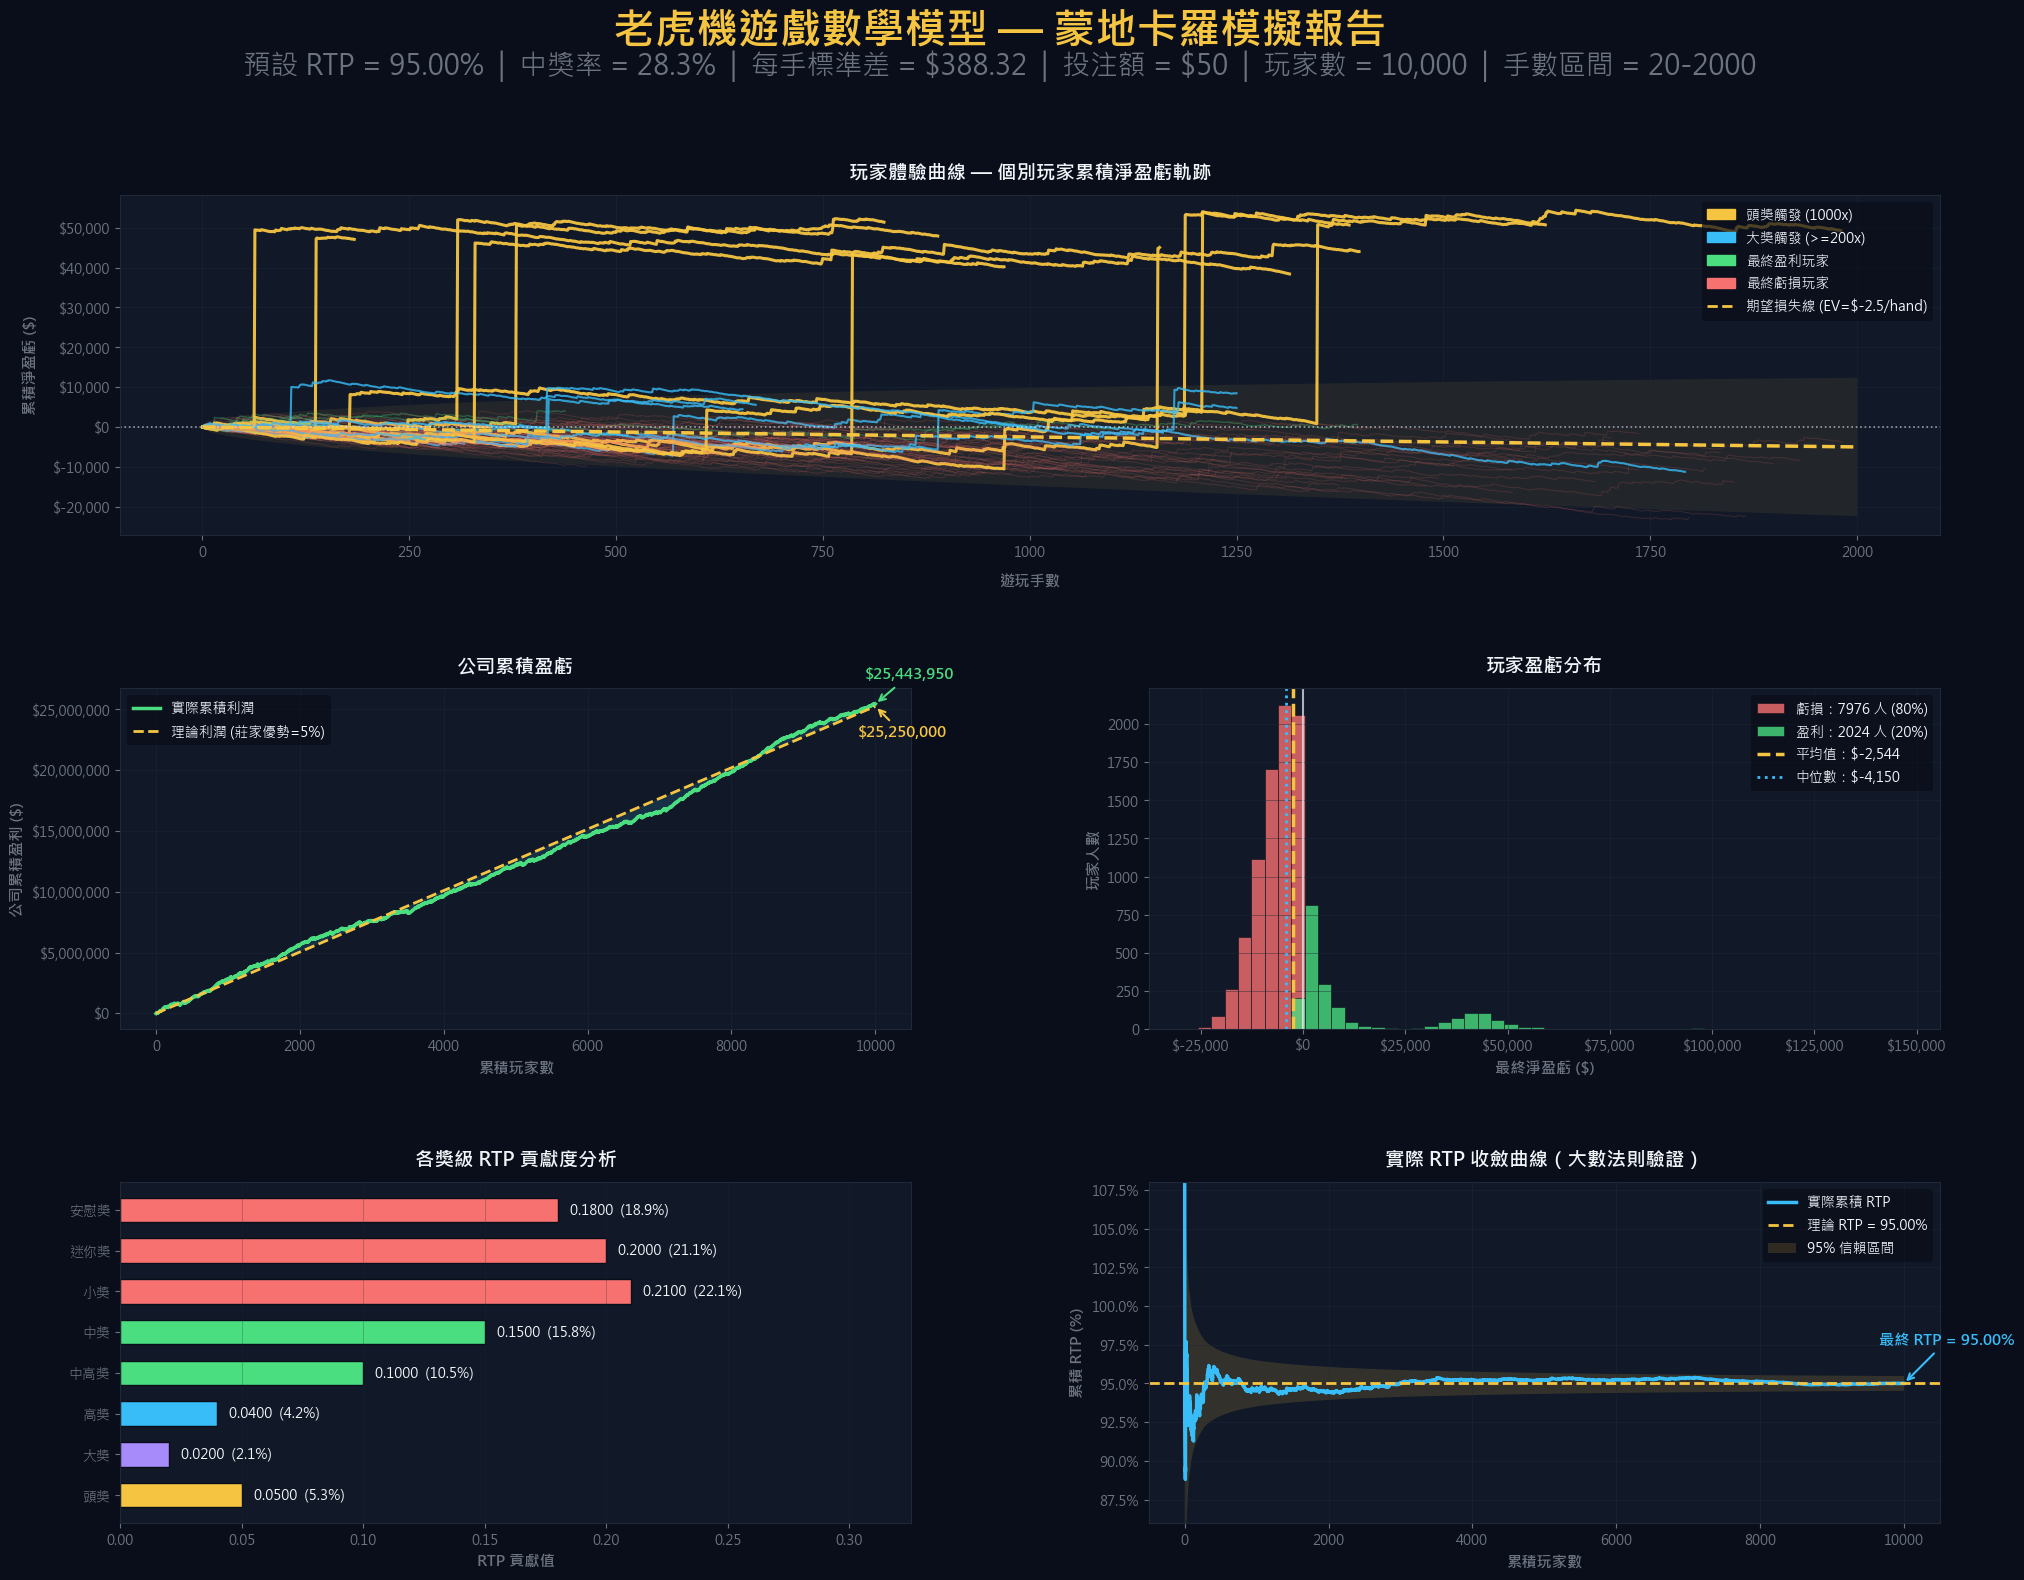

In [ ]:
BG    = '#0a0e1a'
CARD  = '#111827'
GRID  = '#1f2937'
GOLD  = '#f5c542'
CYAN  = '#38bdf8'
RED   = '#f87171'
GREEN = '#4ade80'
PURP  = '#a78bfa'
GREY  = '#6b7280'
WHITE = '#f1f5f9'

dollar_fmt = FuncFormatter(lambda x, _: f'${x:,.0f}')
pct_fmt    = FuncFormatter(lambda x, _: f'{x:.1f}%')

plt.rcParams.update({
    'axes.facecolor':  CARD,
    'axes.edgecolor':  GRID,
    'axes.labelcolor': GREY,
    'axes.titlecolor': WHITE,
    'xtick.color':     GREY,
    'ytick.color':     GREY,
    'grid.color':      GRID,
    'grid.linewidth':  0.6,
    'figure.facecolor': BG,
    'text.color':      WHITE,
    'text.parse_math': False,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.30, left=0.06, right=0.97, top=0.88, bottom=0.05)

# Title
fig.text(0.5, 0.975, '老虎機遊戲數學模型 — 蒙地卡羅模擬報告', ha='center', fontsize=30, fontweight='bold', color=GOLD)
fig.text(0.5, 0.955,
         f'預設 RTP = {rtp*100:.2f}%  |  中獎率 = {hit_freq*100:.1f}%  |  '
         f'每手標準差 = ${sigma*BET:.2f}  |  投注額 = ${BET}  |  '
         f'玩家數 = {N_PLAYERS:,}  |  手數區間 = {MIN_HANDS}-{MAX_HANDS}',
         ha='center', fontsize=20, color=GREY)


# 圖 1：玩家體驗曲線
ax1 = fig.add_subplot(gs[0, :])
ax1.set_title('玩家體驗曲線 — 個別玩家累積淨盈虧軌跡', fontsize=14, pad=12)
ax1.grid(True, alpha=0.5)

sample = np.random.choice(N_PLAYERS, min(SHOW_PLAYERS, N_PLAYERS), replace=False)
for idx in sample:
    p = players_data[idx]
    x = np.arange(1, p['n'] + 1)
    y = p['net']
    if len(p['jackpot']) > 0:
        c, a, lw = GOLD,  0.95, 2.2
    elif len(p['big']) > 0:
        c, a, lw = CYAN,  0.80, 1.5
    elif p['final'] > 0:
        c, a, lw = GREEN, 0.30, 1.0
    else:
        c, a, lw = RED,   0.15, 0.8
    ax1.plot(x, y, color=c, alpha=a, linewidth=lw)

ev_x = np.arange(1, MAX_HANDS + 1)
ev_y = ev_x * BET * (rtp - 1)
ax1.plot(ev_x, ev_y, color=GOLD, lw=2.5, ls='--', label=f'期望值線  EV/hand = ${BET*(rtp-1):.2f}', zorder=10)
ax1.axhline(0, color=WHITE, lw=1.2, ls=':', alpha=0.6)

sigma_y_upper = ev_x * BET * (rtp - 1) + np.sqrt(ev_x) * sigma * BET
sigma_y_lower = ev_x * BET * (rtp - 1) - np.sqrt(ev_x) * sigma * BET
ax1.fill_between(ev_x, sigma_y_lower, sigma_y_upper, color=GOLD, alpha=0.08, label='±1σ 理論波動區間', edgecolor='none')

handles = [
    mpatches.Patch(color=GOLD,  label='頭獎觸發 (1000x)'),
    mpatches.Patch(color=CYAN,  label='大獎觸發 (>=200x)'),
    mpatches.Patch(color=GREEN, label='最終盈利玩家'),
    mpatches.Patch(color=RED,   label='最終虧損玩家'),
    plt.Line2D([0],[0], color=GOLD, ls='--', lw=2, label=f'期望損失線 (EV=${BET*(rtp-1):.1f}/hand)'),
]
ax1.legend(handles=handles, loc='upper right', fontsize=10, facecolor=BG, edgecolor='none', labelcolor=WHITE, framealpha=0.7)
ax1.yaxis.set_major_formatter(dollar_fmt)
ax1.set_xlabel('遊玩手數', fontsize=11, labelpad=10)
ax1.set_ylabel('累積淨盈虧 ($)', fontsize=11, labelpad=10)


# 圖 2：公司累積盈虧
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_title('公司累積盈虧', fontsize=14, pad=12)
ax2.grid(True, alpha=0.5)

ax2.plot(player_nums, company_PNL, color=GREEN, lw=2.5, label='實際累積利潤')
ax2.plot(player_nums, theo_company, color=GOLD, lw=2.0, ls='--', label=f'理論利潤 (莊家優勢={100*(1-rtp):.0f}%)')
ax2.fill_between(player_nums, company_PNL, theo_company, alpha=0.15, color=CYAN, edgecolor='none')

ax2.yaxis.set_major_formatter(dollar_fmt)
ax2.set_xlabel('累積玩家數', fontsize=11)
ax2.set_ylabel('公司累積盈利 ($)', fontsize=11)
ax2.legend(fontsize=10, facecolor=BG, edgecolor='none', labelcolor=WHITE, framealpha=0.7)

final_profit = company_PNL[-1]
ax2.annotate(f'${final_profit:,.0f}',
             xy=(N_PLAYERS, final_profit),
             xytext=(N_PLAYERS - 150, final_profit + abs(final_profit)*0.08),
             color=GREEN, fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5))
final_theo = theo_company[-1]
ax2.annotate(f'${final_theo:,.0f}',
             xy=(N_PLAYERS, final_theo),
             xytext=(N_PLAYERS - 250, final_theo - abs(final_theo)*0.10),
             color=GOLD, fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5))


# 圖 3：玩家最終盈虧分布
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_title('玩家盈虧分布', fontsize=14, pad=12)
ax3.grid(True, alpha=0.5)

n_pos = (final_nets > 0).sum()
n_neg = (final_nets <= 0).sum()

bins = np.linspace(final_nets.min(), final_nets.max(), 55)
ax3.hist(final_nets[final_nets <= 0], bins=bins, color=RED, alpha=0.8,
         label=f'虧損：{n_neg} 人 ({n_neg/N_PLAYERS*100:.0f}%)',
         edgecolor=BG, linewidth=0.5)
ax3.hist(final_nets[final_nets > 0], bins=bins, color=GREEN, alpha=0.8,
         label=f'盈利：{n_pos} 人 ({n_pos/N_PLAYERS*100:.0f}%)',
         edgecolor=BG, linewidth=0.5)
ax3.axvline(final_nets.mean(), color=GOLD, lw=2.5, ls='--',
            label=f'平均值：${final_nets.mean():,.0f}')
ax3.axvline(np.median(final_nets), color=CYAN, lw=2.0, ls=':',
            label=f'中位數：${np.median(final_nets):,.0f}')
ax3.axvline(0, color=WHITE, lw=1.5, alpha=0.7)

ax3.xaxis.set_major_formatter(dollar_fmt)
ax3.set_xlabel('最終淨盈虧 ($)', fontsize=11)
ax3.set_ylabel('玩家人數', fontsize=11)
ax3.legend(fontsize=10, facecolor=BG, edgecolor='none', labelcolor=WHITE, framealpha=0.7)


# 圖 4：各獎級 RTP 貢獻分析
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_title('各獎級 RTP 貢獻度分析', fontsize=14, pad=12)
ax4.grid(True, alpha=0.3, axis='x')

win_names   = [n for n, m in zip(names, mults) if m > 0]
win_contrib = [p * m for p, m, in zip(probs, mults) if m > 0]
win_mults   = [m for m in mults if m > 0]

bar_colors = []
for m in win_mults:
    if m >= 1000: bar_colors.append(GOLD)
    elif m >= 200: bar_colors.append(PURP)
    elif m >= 50:  bar_colors.append(CYAN)
    elif m >= 10:  bar_colors.append(GREEN)
    else:          bar_colors.append(RED)

bars = ax4.barh(win_names, win_contrib, color=bar_colors, edgecolor=BG, height=0.6, linewidth=1)
for bar, val, m in zip(bars, win_contrib, win_mults):
    ax4.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}  ({val/rtp*100:.1f}%)', va='center', ha='left', color=WHITE, fontsize=10)

ax4.set_xlabel('RTP 貢獻值', fontsize=11)
ax4.set_xlim([0, max(win_contrib) * 1.55])


# 圖 5：實際 RTP 收斂曲線
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_title('實際 RTP 收斂曲線', fontsize=14, pad=12)
ax5.grid(True, alpha=0.5)

ax5.plot(player_nums, cum_rtp * 100, color=CYAN, lw=2.5, label='實際累積 RTP')
ax5.axhline(rtp * 100, color=GOLD, lw=2.0, ls='--', label=f'理論 RTP = {rtp*100:.2f}%')

upper_ci = np.clip((rtp + 1.96 * se_arr) * 100, 85, 110)
lower_ci = np.clip((rtp - 1.96 * se_arr) * 100, 85, 110)
ax5.fill_between(player_nums, lower_ci, upper_ci, color=GOLD, alpha=0.15, label='95% 信賴區間', edgecolor='none')

ax5.yaxis.set_major_formatter(pct_fmt)
ax5.set_ylim([86, 108])
ax5.set_xlabel('累積玩家數', fontsize=11)
ax5.set_ylabel('累積 RTP (%)', fontsize=11)
ax5.legend(fontsize=10, facecolor=BG, edgecolor='none', labelcolor=WHITE, framealpha=0.7)

final_rtp_val = cum_rtp[-1] * 100
ax5.annotate(f'最終 RTP = {final_rtp_val:.2f}%',
             xy=(N_PLAYERS, final_rtp_val),
             xytext=(N_PLAYERS - 350, final_rtp_val + 2.5),
             color=CYAN, fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=CYAN, lw=1.5))

plt.tight_layout()
plt.show()

In [7]:
print(f"- 盈利玩家比例　　: {(final_nets>0).mean()*100:.1f}%")
print(f"- 平均最終淨盈虧　: ${final_nets.mean():,.0f}")
print(f"- 中位數淨盈虧　　: ${np.median(final_nets):,.0f}")
print(f"- 最大盈利　　　　: ${final_nets.max():,.0f}")
print(f"- 最大虧損　　　　: ${final_nets.min():,.0f}")
print(f"- 公司總盈利　　　: ${company_PNL[-1]:,.0f}")
print(f"- 實際 RTP       : {cum_rtp[-1]*100:.3f}%")
jackpot_players = sum(len(p['jackpot']) > 0 for p in players_data)
print(f"- 頭獎觸發玩家數　: {jackpot_players}/{N_PLAYERS} 人")

- 盈利玩家比例　　: 20.2%
- 平均最終淨盈虧　: $-2,544
- 中位數淨盈虧　　: $-4,150
- 最大盈利　　　　: $146,900
- 最大虧損　　　　: $-28,900
- 公司總盈利　　　: $25,443,950
- 實際 RTP       : 95.002%
- 頭獎觸發玩家數　: 491/10000 人
